# Car Price Prediction with Machine Learning

A professional end-to-end machine learning project for predicting used car selling prices.

## Objective
Build a regression model that predicts the selling price of a used car using features such as:
- Present price
- Fuel type
- Seller type
- Transmission
- Driven kilometers
- Owner count
- Car age


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

plt.style.use("default")


## 2. Load Dataset

In [2]:
df = pd.read_csv("car_data.csv")
df.head()


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.shape

(301, 9)

In [4]:
df.columns.tolist()

['Car_Name',
 'Year',
 'Selling_Price',
 'Present_Price',
 'Driven_kms',
 'Fuel_Type',
 'Selling_type',
 'Transmission',
 'Owner']

## 3. Understand the Data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.642584,0.32,1.2,6.4,9.9,92.6
Driven_kms,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Selling_type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


In [7]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

## 4. Feature Engineering

In [8]:
current_year = datetime.now().year
df['Car_Age'] = current_year - df['Year']

# Remove columns that are not needed for the model
df = df.drop(['Year', 'Car_Name'], axis=1)

df.head()


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


## 5. Exploratory Data Analysis

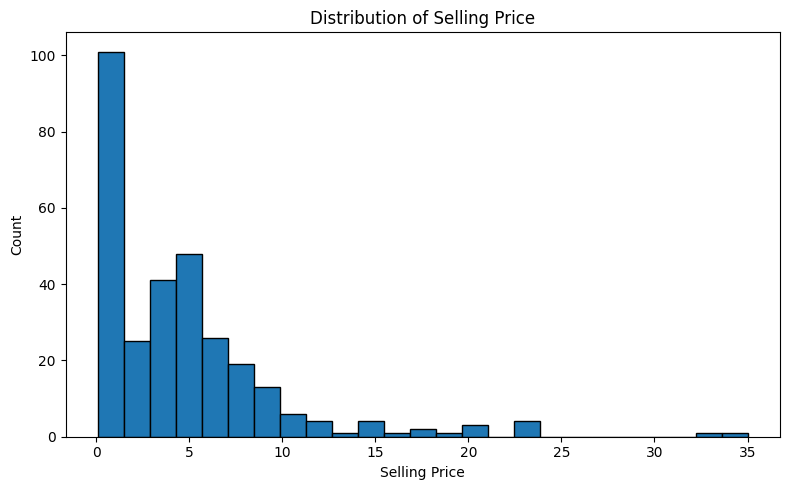

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df['Selling_Price'], bins=25, edgecolor='black')
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


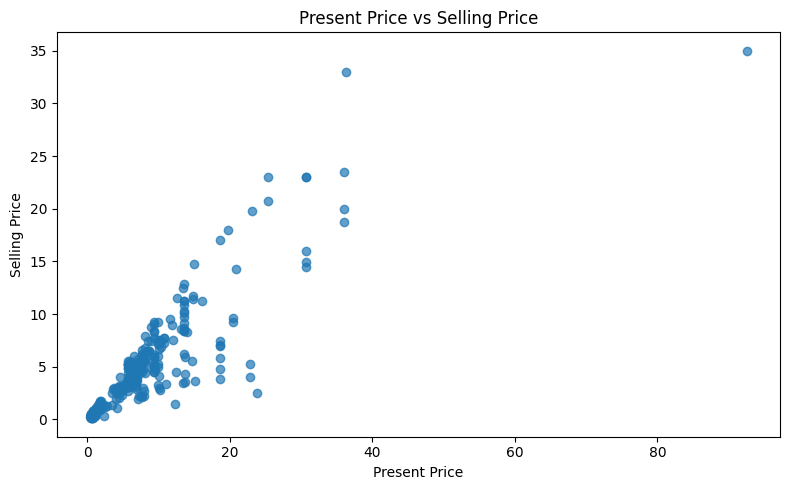

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Present_Price'], df['Selling_Price'], alpha=0.7)
plt.title('Present Price vs Selling Price')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')
plt.tight_layout()
plt.show()


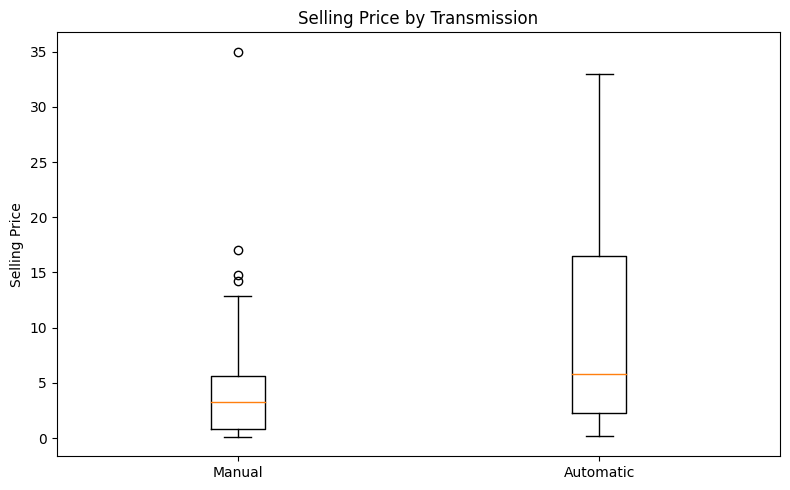

In [11]:
plt.figure(figsize=(8, 5))
manual = df[df['Transmission'] == 'Manual']['Selling_Price']
automatic = df[df['Transmission'] == 'Automatic']['Selling_Price']
plt.boxplot([manual, automatic], labels=['Manual', 'Automatic'])
plt.title('Selling Price by Transmission')
plt.ylabel('Selling Price')
plt.tight_layout()
plt.show()


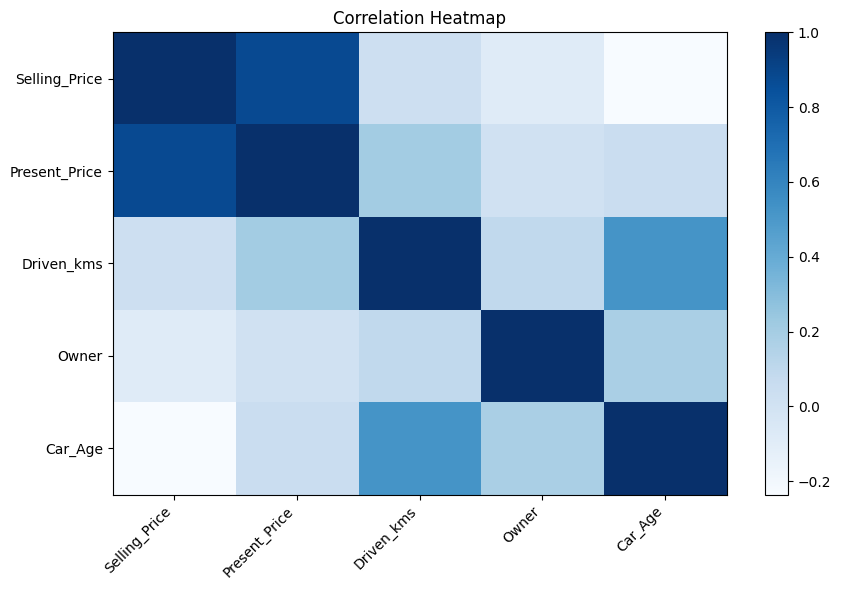

In [12]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

plt.figure(figsize=(9, 6))
im = plt.imshow(corr, cmap='Blues', aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


## 6. Prepare Features and Target

In [13]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

categorical_features = ['Fuel_Type', 'Selling_type', 'Transmission']
numeric_features = ['Present_Price', 'Driven_kms', 'Owner', 'Car_Age']

X.head()


,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,5.59,27000,Petrol,Dealer,Manual,0,12
1,9.54,43000,Diesel,Dealer,Manual,0,13
2,9.85,6900,Petrol,Dealer,Manual,0,9
3,4.15,5200,Petrol,Dealer,Manual,0,15
4,6.87,42450,Diesel,Dealer,Manual,0,12


## 7. Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((240, 7), (61, 7))

## 8. Build ML Pipeline

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features),
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_features)
    ]
)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}


## 9. Train and Compare Models

In [16]:
results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds, squared=False)
    r2 = r2_score(y_test, preds)
    cv_r2 = cross_val_score(pipeline, X, y, cv=5, scoring='r2').mean()

    results.append({
        'Model': name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R2': round(r2, 4),
        'CV_R2_Mean': round(cv_r2, 4)
    })

results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)
results_df


,Model,MAE,RMSE,R2,CV_R2_Mean
2,Gradient Boosting,0.5829,0.9268,0.9627,0.4071
1,Random Forest,0.6398,0.9811,0.9582,0.3625
0,Linear Regression,1.2164,1.8658,0.8489,-18.1498


## 10. Fit the Best Model

In [17]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_model)
])

final_pipeline.fit(X_train, y_train)
final_predictions = final_pipeline.predict(X_test)

print("Best Model:", best_model_name)
print("MAE:", round(mean_absolute_error(y_test, final_predictions), 4))
print("RMSE:", round(mean_squared_error(y_test, final_predictions, squared=False), 4))
print("R2 Score:", round(r2_score(y_test, final_predictions), 4))


Best Model: Gradient Boosting
MAE: 0.5829
RMSE: 0.9268
R2 Score: 0.9627


## 11. Actual vs Predicted

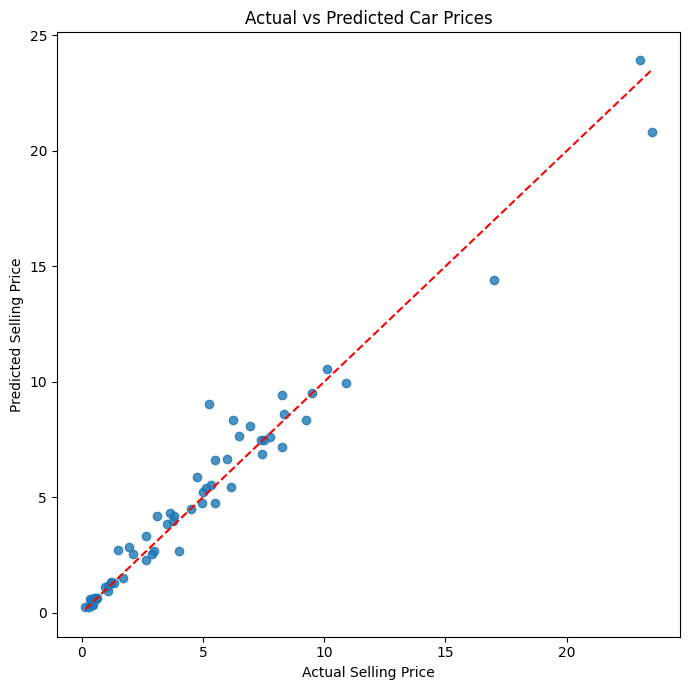

In [18]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, final_predictions, alpha=0.8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs Predicted Car Prices')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.tight_layout()
plt.show()


## 12. Example Prediction

In [19]:
sample_car = pd.DataFrame([{
    'Present_Price': 10.0,
    'Driven_kms': 30000,
    'Fuel_Type': 'Petrol',
    'Selling_type': 'Dealer',
    'Transmission': 'Manual',
    'Owner': 0,
    'Car_Age': 5
}])

predicted_price = final_pipeline.predict(sample_car)[0]
print(f'Predicted Selling Price: {predicted_price:.2f}')


Predicted Selling Price: 7.68


## 13. Conclusion

This project demonstrates a professional machine learning workflow:
- Data loading
- Data inspection
- Feature engineering
- Exploratory data analysis
- Model comparison
- Final prediction

The tree-based models usually perform better than linear regression for this dataset.
